## Mnist dataset which is set of 70,000 small images of digits handwritten by high school student and employess of the census Bureau . Each image is labeled with the digit it represent

In [1]:
import numpy as numpy
from sklearn.datasets import fetch_openml
mnist= fetch_openml('mnist_784',version=1,as_frame=False)

In [2]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
x,y=mnist['data'],mnist['target']

In [4]:
x.shape

(70000, 784)

In [5]:
y.shape

(70000,)

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mppl

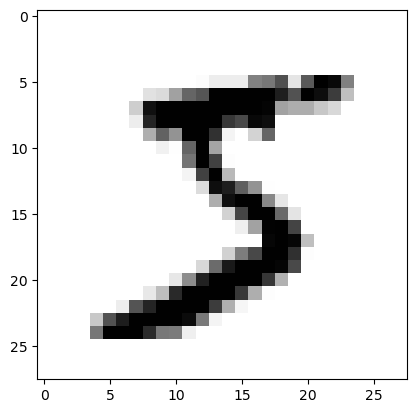

In [7]:
some_digit=x[0]
some_digit_image=some_digit.reshape(28,28) #784 to shape 28*28
plt.imshow(some_digit_image,cmap='binary')
plt.show()

In [8]:
y[0]

'5'

In [9]:
x_train,x_test,y_train,y_test=x[:60000],x[60000:],y[:60000],y[60000:]

In [10]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((60000, 784), (10000, 784), (60000,), (10000,))

In [11]:
y_train[:10]

array(['5', '0', '4', '1', '9', '2', '1', '3', '1', '4'], dtype=object)

In [12]:
#converting the trainingg dataset string to integer
y_train_int=y_train.astype(int)
y_test_int=y_test.astype(int)

In [13]:
x_train_dumy=x_train/255.0
x_test_dumy=x_test/255.0

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
log_reg=LogisticRegression(max_iter=100,solver='lbfgs')

In [16]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
log_reg.fit(x_train_dumy,y_train_int)

LogisticRegression()

In [18]:
from sklearn.metrics import accuracy_score


In [19]:
y_pred=log_reg.predict(x_test_dumy)

In [20]:
accuracy=accuracy_score(y_test_int,y_pred)

In [21]:
print("Accuracy:",accuracy*100)

Accuracy: 92.57


In [22]:
sample=x_test_dumy[0].reshape(1,-1)
probablities=log_reg.predict_proba(sample)
print(probablities)


[[8.12064763e-07 7.42314267e-13 2.18924963e-06 1.74219251e-03
  1.04539468e-07 1.19591265e-05 1.31897976e-11 9.97977503e-01
  9.75603698e-06 2.55483207e-04]]


In [23]:

print("Actual",y_test_int[0])
print("Predicted",log_reg.predict(sample)[0])

Actual 7
Predicted 7


In [24]:
from sklearn.metrics import confusion_matrix

In [25]:
cm=confusion_matrix(y_test_int,y_pred)

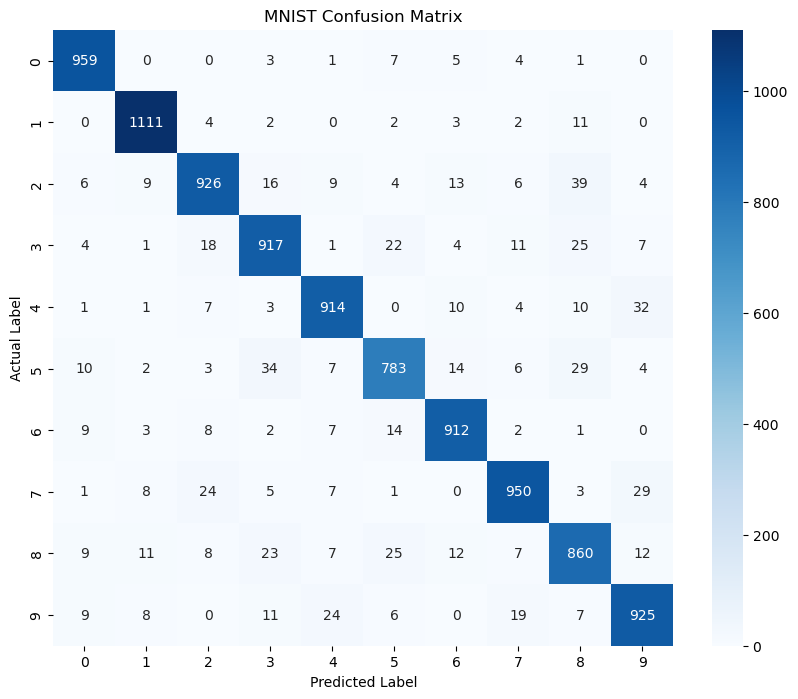

In [26]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=range(10), yticklabels=range(10),  )
plt.xlabel("Predicted Label") 
plt.ylabel("Actual Label") 
plt.title("MNIST Confusion Matrix") 
plt.show()

In [27]:
from sklearn.metrics import classification_report

In [28]:
print("--- Classification Report ---")
print(
    classification_report(
        y_test_int,
        y_pred,
        target_names=[f"Digit {i}" for i in range(10)],
    )
)

--- Classification Report ---
              precision    recall  f1-score   support

     Digit 0       0.95      0.98      0.96       980
     Digit 1       0.96      0.98      0.97      1135
     Digit 2       0.93      0.90      0.91      1032
     Digit 3       0.90      0.91      0.91      1010
     Digit 4       0.94      0.93      0.93       982
     Digit 5       0.91      0.88      0.89       892
     Digit 6       0.94      0.95      0.94       958
     Digit 7       0.94      0.92      0.93      1028
     Digit 8       0.87      0.88      0.88       974
     Digit 9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(400, 795, 3)


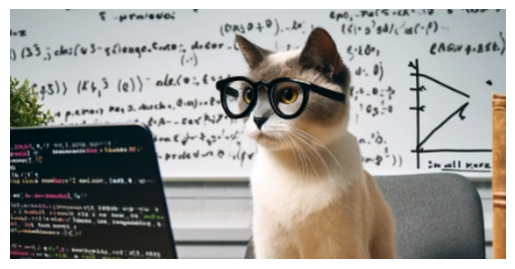

In [31]:
image=cv2.imread('dataset-cover (1).jpg')
print(image.shape)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [32]:
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

blur=cv2.GaussianBlur(gray,(5,5),0)

_,threshold=cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

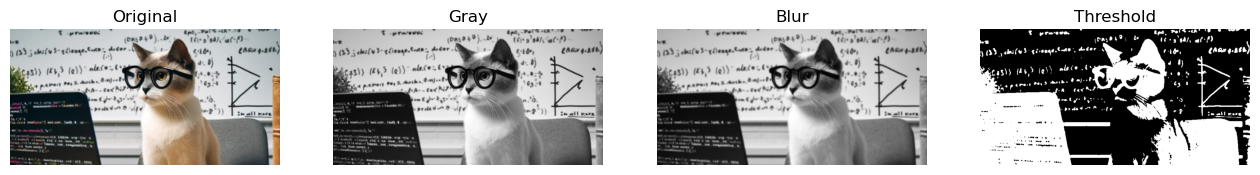

In [33]:
plt.figure(figsize=(16,4))
plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")
plt.subplot(1,4,2)
plt.imshow(gray,cmap="gray")
plt.title("Gray")
plt.axis("off")
plt.subplot(1,4,3)
plt.imshow(blur,cmap="gray")
plt.title("Blur")
plt.axis("off")
plt.subplot(1,4,4)
plt.imshow(threshold,cmap="gray")
plt.title("Threshold")
plt.axis("off")
plt.show()

In [34]:
contours,_=cv2.findContours(
    threshold,
    cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

print("Number of Contours:",len(contours))



Number of Contours: 257


In [35]:
largest_contours=max(contours,key=cv2.contourArea)
x,y,w,h=cv2.boundingRect(largest_contours)


In [36]:
print("Bounding box")
print("x",x)
print("y",y)
print("width",w)
print("height",h)

Bounding box
x 0
y 108
width 391
height 292


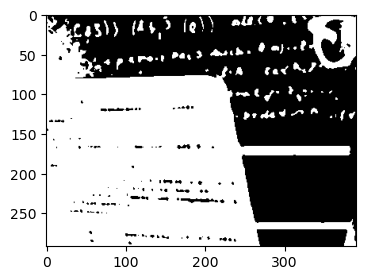

In [37]:
# crop the image:
corp_digit=threshold[y:y+h,x:x+w]
#display the cropped digit
plt.figure(figsize=(4,4))
plt.imshow(corp_digit,cmap="gray")
plt.show()


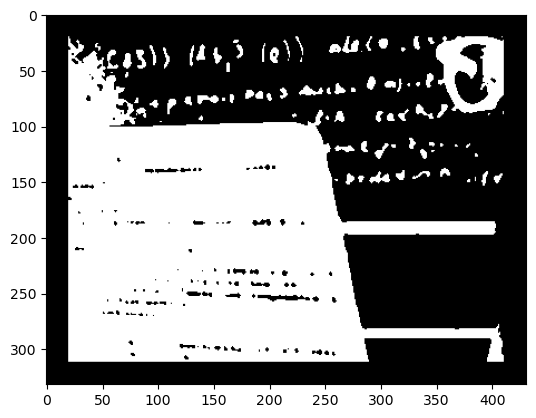

In [38]:
# add padding to the image
padding=20
digit_padded=cv2.copyMakeBorder(corp_digit,padding,padding,padding,padding,cv2.BORDER_CONSTANT,value=0)
plt.imshow(digit_padded,cmap='gray')
plt.show()

Shape: (28, 28)


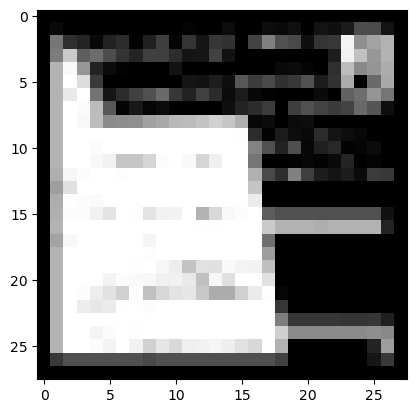

In [39]:
# reshape the padded  image
digit_28=cv2.resize(digit_padded,(28,28),interpolation=cv2.INTER_AREA)
print("Shape:",digit_28.shape)

plt.imshow(digit_28,cmap='gray')
plt.show()